# Week 3: Statistics & Probability Analysis

## Objective

The objective of this notebook is to apply statistical concepts to the cleaned Titanic and Housing Price datasets.
The analysis covers descriptive statistics, probability distributions, hypothesis testing, and correlation analysis using Python.

# Part A: Titanic Dataset

## 1. Import Required Libraries
The following libraries are used for data manipulation, statistical analysis, and visualization.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The cleaned Titanic dataset is loaded into a pandas DataFrame for statistical analysis.

In [45]:
df = pd.read_csv("titanic_cleaned.csv")

## 3. Dataset Preview

The first five rows are displayed to verify that the dataset has been loaded correctly.

In [46]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown


##  Task 1: Descriptive Statistics

Descriptive statistics summarize the main characteristics of the dataset. In this section, the mean, median, mode, variance, standard deviation, and range are calculated for selected variables.

In [47]:
# summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.135432,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.490884,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.750000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Mean

In [48]:
print("Mean Age:", df["Age"].mean())
print("Mean Fare:", df["Fare"].mean())

Mean Age: 29.13543209876543
Mean Fare: 32.204207968574636


## Median

In [49]:
print("Median Age:", df["Age"].median())
print("Median Fare:", df["Fare"].median())

Median Age: 26.0
Median Fare: 14.4542


## Mode

In [50]:
print("Most occurring gender:", df["Sex"].mode().iloc[0])
print("Most occurring port:", df["Embarked"].mode().iloc[0])
print("Most occurring class:", df["Pclass"].mode().iloc[0])
print("Most occurring deck:", df["Deck"].mode().iloc[0])

Most occurring gender: male
Most occurring port: S
Most occurring class: 3
Most occurring deck: Unknown


## Variance

In [51]:
print("Age Variance:", df["Age"].var())
print("Fare Variance:", df["Fare"].var())

Age Variance: 182.0039572007216
Fare Variance: 2469.436845743117


## Standard Deviation

In [52]:
print("Age Standard Deviation:", df["Age"].std())
print("Fare Standard Deviation:", df["Fare"].std())

Age Standard Deviation: 13.490884226051367
Fare Standard Deviation: 49.693428597180905


## Range

In [53]:
print("Age Range:", df["Age"].max() - df["Age"].min())
print("Fare Range:", df["Fare"].max() - df["Fare"].min())

Age Range: 79.58
Fare Range: 512.3292


## Task 2: Probability Distributions

Probability distributions describe how values of a variable are spread across a dataset. Visualizing these distributions helps identify patterns such as symmetry, skewness, spread, and the presence of outliers.

In this section, the distributions of **Age** and **Fare** are examined using histograms with Kernel Density Estimation (KDE) curves.

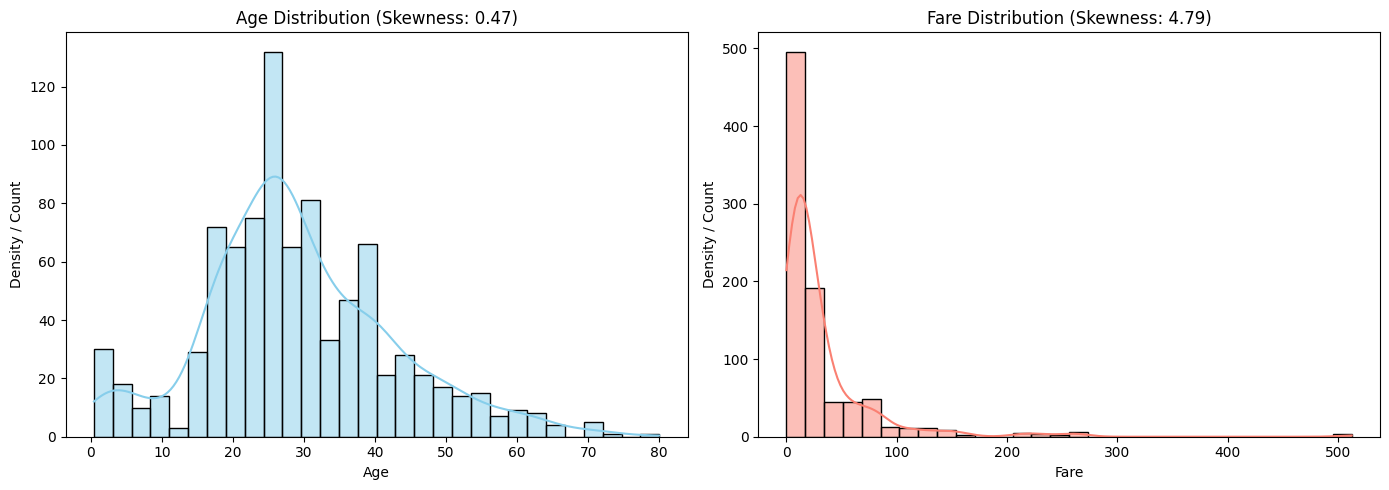

In [54]:
# Set up a grid for 2 plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age Distribution
sns.histplot(df["Age"], kde=True, ax=axes[0], color="skyblue", bins=30)
axes[0].set_title(f"Age Distribution (Skewness: {df['Age'].skew():.2f})")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density / Count")

# Plot 2: Fare Distribution
sns.histplot(df["Fare"], kde=True, ax=axes[1], color="salmon", bins=30)
axes[1].set_title(f"Fare Distribution (Skewness: {df['Fare'].skew():.2f})")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Density / Count")

plt.tight_layout()
plt.show()

### Summary of Probability Distributions
- The **Age** distribution is approximately bell-shaped with a slight right skew, indicating that most passengers were young to middle-aged.
- The **Fare** distribution is highly right-skewed, with most passengers paying lower fares and a small number paying significantly higher fares.
- The boxplots reveal several outliers in the **Fare** variable, while the **Age** variable contains fewer extreme values.
- These distribution patterns provide useful insights into passenger demographics and ticket pricing on the Titanic.

## Task 3: Hypothesis Testing (Gender vs. Age)

We will perform an **Independent Two-Sample T-Test** to determine if there is a statistically significant difference between the mean age of male and female passengers.

*   **Null Hypothesis ($H_0$):** There is no difference in the average age between male and female passengers ($\mu_{\text{male}} = \mu_{\text{female}}$).
*   **Alternative Hypothesis ($H_1$):** There is a statistically significant difference in the average age between male and female passengers ($\mu_{\text{male}} \neq \mu_{\text{female}}$).
*   **Significance Level ($\alpha$):** 0.05

In [55]:
from scipy import stats

# 1. Separate the Age data into two groups based on Gender
male_age = df[df["Sex"] == "male"]["Age"]
female_age = df[df["Sex"] == "female"]["Age"]

# 2. Run an Independent T-Test (Welch's T-test)
t_stat, p_val = stats.ttest_ind(male_age, female_age, equal_var=False)

# 3. Print the results cleanly
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print("-" * 40)

# 4. Automated interpretation conclusion
if p_val < 0.05:
    print(
        "Conclusion: Reject the Null Hypothesis (H0).\n"
        "There is a statistically significant difference in the average age between male and female passengers."
    )
else:
    print(
        "Conclusion: Fail to reject the Null Hypothesis (H0).\n"
        "There is no statistically significant difference in the average age between male and female passengers."
    )

T-statistic: 3.0929
P-value: 0.0021
----------------------------------------
Conclusion: Reject the Null Hypothesis (H0).
There is a statistically significant difference in the average age between male and female passengers.


## Task 4: Correlation vs. Causation
We will calculate Pearson's correlation coefficient for the numerical features in the dataset and visualize the relationships using a heatmap.

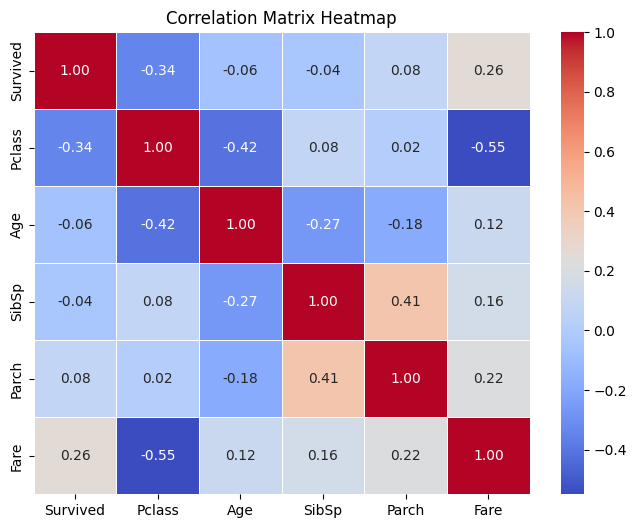

In [56]:
# 1. Select relevant numerical columns for correlation analysis
numerical_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df[numerical_cols].corr()

# 2. Plot the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

### Interpretation and Analysis

*   **Correlation:** The heatmap reveals notable linear relationships. For instance, there is a positive correlation between `Fare` and `Survived` (higher fare tends to align with higher survival rates) and a strong negative correlation between `Pclass` and `Fare` (First-class tickets cost significantly more).
*   **Causation:** While `Fare` and `Survived` are positively correlated, paying a higher fare did not *directly cause* a passenger to survive the disaster. 

**The Causal Mechanism:**
The true underlying causal factors were structural and procedural:
1.  **Ticket Class Privilege (`Pclass`):** Higher fares granted access to first-class cabins, which were located physically closer to the boat deck where lifeboats were launched. 
2.  **Evacuation Policy:** The "women and children first" protocol was the actual driving causal mechanism for survival, rather than the monetary value of a ticket itself. 

This perfectly demonstrates the data science rule: **Correlation does not imply causation**. A strong statistical correlation often points to a hidden confounding variable (`Pclass` or cabin location) rather than a direct cause-and-effect link.

# Part B: Housing Price Dataset

## Objective

The objective of this section is to apply descriptive statistics, probability distributions, hypothesis testing, and correlation analysis to the cleaned Housing Price dataset in order to understand the characteristics of house prices and the relationships between important variables.

In [57]:
# load and preview dataset
housing_df = pd.read_csv("Cleaned_Housing_Dataset")
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Task 1: Descriptive Statistics

In [58]:
# 1. Mean
print("--- Means ---")
print(f"Mean House Price: ${housing_df['price'].mean():,.2f}")
print(f"Mean Property Area: {housing_df['area'].mean():,.2f} sq ft\n")

# 2. Mode
print("--- Modes ---")
print("Most common furnishing status:", housing_df["furnishingstatus"].mode().iloc[0])
print("Most common number of bedrooms:", housing_df["bedrooms"].mode().iloc[0])
print("Most common air conditioning setup:", housing_df["airconditioning"].mode().iloc[0], "\n")

# 3. Variance & Standard Deviation
print("--- Dispersion ---")
print(f"Price Variance: {housing_df['price'].var():,.2f}")
print(f"Price Std Dev: ${housing_df['price'].std():,.2f}")
print(f"Area Variance: {housing_df['area'].var():,.2f}")
print(f"Area Std Dev: {housing_df['area'].std():,.2f} sq ft\n")

# 4. Range
price_range = housing_df["price"].max() - housing_df["price"].min()
area_range = housing_df["area"].max() - housing_df["area"].min()

print("--- Ranges ---")
print(f"Price Range: ${price_range:,.2f} (Span: ${housing_df['price'].min():,} to ${housing_df['price'].max():,})")
print(f"Area Range: {area_range:,} sq ft (Span: {housing_df['area'].min():,} to {housing_df['area'].max():,})")

--- Means ---
Mean House Price: $4,766,729.25
Mean Property Area: 5,150.54 sq ft

--- Modes ---
Most common furnishing status: semi-furnished
Most common number of bedrooms: 3
Most common air conditioning setup: no 

--- Dispersion ---
Price Variance: 3,498,544,355,820.58
Price Std Dev: $1,870,439.62
Area Variance: 4,709,512.06
Area Std Dev: 2,170.14 sq ft

--- Ranges ---
Price Range: $11,550,000.00 (Span: $1,750,000 to $13,300,000)
Area Range: 14,550 sq ft (Span: 1,650 to 16,200)


## Task 2: Probability Distributions

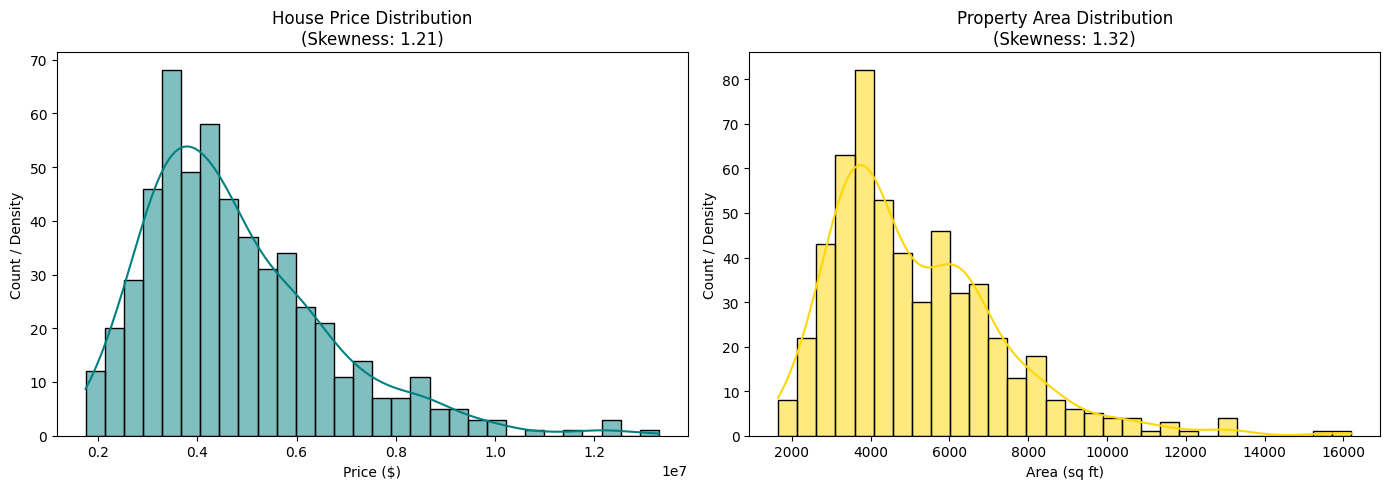

In [59]:
# Set up a grid for 2 plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price Distribution
sns.histplot(housing_df["price"], kde=True, ax=axes[0], color="teal", bins=30)
axes[0].set_title(
    f"House Price Distribution\n(Skewness: {housing_df['price'].skew():.2f})"
)
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count / Density")

# Plot 2: Area Distribution
sns.histplot(housing_df["area"], kde=True, ax=axes[1], color="gold", bins=30)
axes[1].set_title(
    f"Property Area Distribution\n(Skewness: {housing_df['area'].skew():.2f})"
)
axes[1].set_xlabel("Area (sq ft)")
axes[1].set_ylabel("Count / Density")

plt.tight_layout()
plt.show()

## Task 3: Hypothesis Testing (Air Conditioning vs. Price)

We will perform an **Independent Two-Sample T-Test** to determine if there is a statistically significant difference between the mean house prices of properties with air conditioning versus those without.

*   **Null Hypothesis ($H_0$):** There is no difference in the average house price between homes with air conditioning and homes without ($\mu_{\text{AC}} = \mu_{\text{No AC}}$).
*   **Alternative Hypothesis ($H_1$):** There is a statistically significant difference in the average house price between homes with air conditioning and homes without ($\mu_{\text{AC}} \neq \mu_{\text{No AC}}$).
*   **Significance Level ($\alpha$):** 0.05

In [60]:
# 1. Separate the Price data into two groups based on Air Conditioning
ac_yes = housing_df[housing_df["airconditioning"] == "yes"]["price"]
ac_no = housing_df[housing_df["airconditioning"] == "no"]["price"]

# 2. Run an Independent T-Test (Welch's T-test)
t_stat, p_val = stats.ttest_ind(ac_yes, ac_no, equal_var=False)

# 3. Print the results cleanly
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print("-" * 40)

# 4. Automated interpretation conclusion
if p_val < 0.05:
    print(
        "Conclusion: Reject the Null Hypothesis (H0).\n"
        "There is a statistically significant difference in house prices based on air conditioning."
    )
else:
    print(
        "Conclusion: Fail to reject the Null Hypothesis (H0).\n"
        "There is no statistically significant difference in house prices based on air conditioning."
    )

T-statistic: 10.6592
P-value: 0.0000
----------------------------------------
Conclusion: Reject the Null Hypothesis (H0).
There is a statistically significant difference in house prices based on air conditioning.


## Task 4: Correlation vs. Causation
We will calculate Pearson's correlation coefficient for the numerical features in the housing dataset and visualize their relationships using a heatmap.

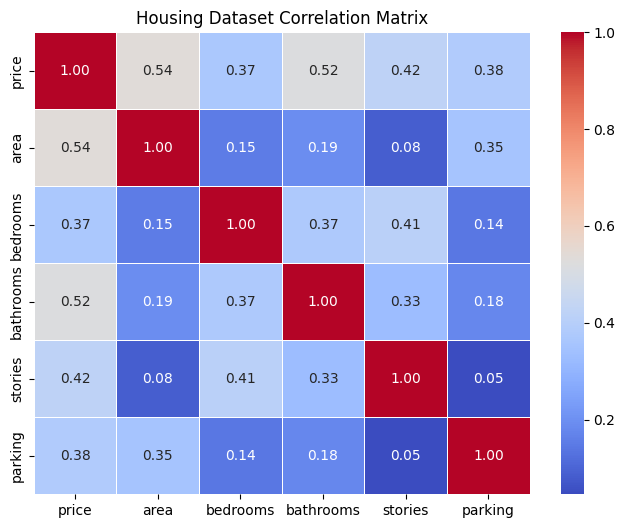

In [61]:
# 1. Select the primary numerical columns for correlation analysis
numerical_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
corr_matrix = housing_df[numerical_cols].corr()

# 2. Plot the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Housing Dataset Correlation Matrix")
plt.show()

### Interpretation and Analysis

*   **Correlation:** The heatmap highlights positive correlations between `price` and variables like `area` (larger houses cost more) and `bathrooms`. There is a clear statistical trend linking these features together.
*   **Causation vs. Correlation:** While a strong correlation exists between having more parking spaces/garages (`parking`) and higher house prices, building a garage onto a house does not entirely explain or directly *cause* a massive spike in property valuation by itself. 

**The Causal Mechanism:**
In real estate data, multiple factors act as confounding elements:
1.  **Affluence and Luxury Status:** Houses with more garages or air conditioning systems are typically built on larger lots (`area`) in wealthier neighborhoods. 
2.  **Cumulative Value:** The higher price is caused by the *overall profile* of the luxury asset (prime location, higher square footage, quality of materials) rather than the isolated addition of a single feature.

This confirms the core data science takeaway: **Correlation does not imply causation**. Strong statistical dependencies often point to underlying property dimensions and luxury classifications rather than a simple cause-and-effect link.